# Quantitative Evaluation

## FID, Precision, Recall, and Conditional Accuracy

This notebook evaluates and compares two conditional image generation models on Fashion-MNIST:
- **Conditional GAN** (with gradient penalty, label smoothing, and instance noise)
- **Conditional diffusion (improved)** — cosine schedule, U-Net 28×28, **DDIM** sampling, weights from `ConditionalDiffusionImproved.ipynb`

**Local setup:** checkpoints under `models/`:
- `gan_generator_best.pth`, `gan_discriminator_best.pth`
- `conditional_diffusion_improved_final.pt` (uses **EMA** weights for generation)

Paths are resolved from the notebook working directory or a parent folder.

We compute standard metrics to quantify sample quality, diversity, and conditioning accuracy.


In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy.linalg import sqrtm
import os
import copy
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def find_models_dir():
    """Resolve ./models from notebook cwd or a parent (works if kernel cwd varies)."""
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        d = base / "models"
        if (d / "gan_generator_best.pth").is_file() or (
            d / "conditional_diffusion_improved_final.pt"
        ).is_file():
            return d
    return cwd / "models"


MODELS_DIR = find_models_dir()
print(f"Models directory: {MODELS_DIR}")

ASSETS_DIR = "assets"
os.makedirs(ASSETS_DIR, exist_ok=True)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Constants
BATCH_SIZE = 128
NUM_CLASSES = 10
IMG_SIZE = 28
CHANNELS = 1
NUM_SAMPLES = 10000  # Total samples to generate (1000 per class)

NULL_LABEL = 10  # unconditional token for improved U-Net / CFG (must match checkpoint)

# Improved diffusion uses DDIM in eval (far fewer steps than full DDPM).
DDIM_EVAL_STEPS = 100
EVAL_GUIDANCE_SCALE = 1.0


Using device: cpu
Models directory: C:\Users\user\Conditional-Image-Synthesis-Benchmarking-Adversarial-vs.-Diffusion-Approaches\models


In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1] for consistency
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 60000
Test samples: 10000


## 1. Load Pre-trained Models

In [10]:
class Generator(nn.Module):
    """Conditional Generator for Fashion-MNIST"""
    def __init__(self, z_dim=256, num_classes=10, img_size=28, channels=1, embed_dim=32):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)  # embed_dim=32
        self.init_size = img_size // 4  # 7
        
        self.l1 = nn.Sequential(
            nn.Linear(z_dim + embed_dim, 128 * self.init_size ** 2),
            nn.BatchNorm1d(128 * self.init_size ** 2),
            nn.ReLU(inplace=True),
        )
        
        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, channels, 4, stride=2, padding=1),
            nn.Tanh(),
        )
    
    def forward(self, z, labels):
        label_emb = self.label_emb(labels)
        gen_input = torch.cat((z, label_emb), dim=1)
        out = self.l1(gen_input)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        return self.conv_blocks(out)


class Discriminator(nn.Module):
    """Conditional Discriminator for Fashion-MNIST"""
    def __init__(self, img_size=28, channels=1, num_classes=10, embed_dim=32):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        self.img_size = img_size
        
        # Project embedding to image size
        self.label_projection = nn.Sequential(
            nn.Linear(embed_dim, img_size * img_size),
            nn.LeakyReLU(0.2),
        )
        
        # Discriminator with BatchNorm
        self.model = nn.Sequential(
            nn.Conv2d(channels + 1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * (img_size // 4) * (img_size // 4), 1),
        )
    
    def forward(self, img, labels):
        label_emb = self.label_emb(labels)
        label_map = self.label_projection(label_emb)
        label_map = label_map.view(-1, 1, self.img_size, self.img_size)
        x = torch.cat((img, label_map), dim=1)
        return self.model(x)


# Load GAN models
z_dim = 256
embed_dim = 32

G = Generator(z_dim, NUM_CLASSES, IMG_SIZE, CHANNELS, embed_dim).to(device)
D = Discriminator(IMG_SIZE, CHANNELS, NUM_CLASSES, embed_dim).to(device)

gan_gen_path = MODELS_DIR / "gan_generator_best.pth"
gan_disc_path = MODELS_DIR / "gan_discriminator_best.pth"
for p in (gan_gen_path, gan_disc_path):
    if not p.is_file():
        raise FileNotFoundError(
            f"Missing {p}. Expected GAN weights in models/ next to this project."
        )

G.load_state_dict(torch.load(str(gan_gen_path), map_location=device))
D.load_state_dict(torch.load(str(gan_disc_path), map_location=device))

G.eval()
D.eval()
print("GAN models loaded successfully!")

GAN models loaded successfully!


In [11]:
import math
import copy
import torch.nn.functional as F
from einops import rearrange

import torch.nn.functional as F

class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


class Upsample(nn.Module):
    """Nearest resize + conv avoids ConvTranspose2d checkerboard / vertical striping."""

    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv2d(dim, dim, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        return self.conv(x)


def Downsample(dim):
    return nn.Conv2d(dim, dim, 4, 2, 1)


class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
        self.b = nn.Parameter(torch.zeros(1, dim, 1, 1))

    def forward(self, x):
        var = torch.var(x, dim=1, unbiased=False, keepdim=True)
        mean = torch.mean(x, dim=1, keepdim=True)
        return (x - mean) / (var + self.eps).sqrt() * self.g + self.b


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


class ConvBlock(nn.Sequential):
    def __init__(self, in_channel, out_channel, kern_size, padd, groups, downsample=True, use_act=True):
        super().__init__()
        self.add_module(
            "conv",
            nn.Conv2d(
                in_channel,
                out_channel,
                kern_size,
                stride=2 if downsample else 1,
                padding=padd,
                groups=groups,
            ),
        )
        self.add_module("norm", nn.GroupNorm(groups, out_channel))
        self.add_module("act", nn.SiLU() if use_act else nn.Identity())


class ResnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, *, time_emb_dim=None, groups=8, downsample=False):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_channels))
            if time_emb_dim is not None
            else None
        )

        self.block1 = ConvBlock(in_channels, out_channels, 3, 1, groups, downsample=downsample)
        self.block2 = ConvBlock(out_channels, out_channels, 3, 1, groups, downsample=False, use_act=False)

        if in_channels != out_channels or downsample:
            self.res_conv = nn.Conv2d(
                in_channels, out_channels, kernel_size=1, stride=2 if downsample else 1
            )
        else:
            self.res_conv = nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, time_emb=None):
        res = self.res_conv(x)

        h = self.block1(x)
        if self.mlp is not None and time_emb is not None:
            time_emb = self.mlp(time_emb)
            h = h + time_emb[:, :, None, None]
        h = self.act(h)
        h = self.block2(h)

        return h + res


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)
        sim = torch.einsum("b h d i, b h d j -> b h i j", q, k) * self.scale
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)
        out = torch.einsum("b h i j, b h d j -> b h i d", attn, v)
        out = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)


class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1), LayerNorm(dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)


class Unet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, null_label=NULL_LABEL):
        super().__init__()
        self.null_label = null_label

        time_dim = 32 * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(32),
            nn.Linear(32, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(1, 32, kernel_size=1)

        self.down1 = ResnetBlock(32, 64, time_emb_dim=time_dim, downsample=True)
        self.attn1 = LinearAttention(64)
        self.down2 = ResnetBlock(64, 128, time_emb_dim=time_dim, downsample=True)
        self.attn2 = LinearAttention(128)
        self.down3 = ResnetBlock(128, 256, time_emb_dim=time_dim, downsample=True)
        self.attn3 = LinearAttention(256)

        self.bottleneck = ResnetBlock(256, 512, time_emb_dim=time_dim, downsample=False)
        self.attn_bottle = Attention(512)

        self.upsample1_op = Upsample(512)
        self.up1 = ResnetBlock(512 + 128, 256, time_emb_dim=time_dim, downsample=False)

        self.upsample2_op = Upsample(256)
        self.up2 = ResnetBlock(256 + 64, 128, time_emb_dim=time_dim, downsample=False)

        self.upsample3_op = Upsample(128)
        self.up3 = ResnetBlock(128 + 32, 64, time_emb_dim=time_dim, downsample=False)

        self.final_res = ResnetBlock(64, 32, time_emb_dim=time_dim, downsample=False)
        self.final_conv = nn.Conv2d(32, 1, 1)

        self.label_emb = nn.Embedding(num_classes + 1, time_dim)

    def forward(self, x, t, y):
        t_emb = self.time_mlp(t.float())
        t_emb = t_emb + self.label_emb(y)

        x_initial_conv_out = self.init_conv(x)
        h = x_initial_conv_out

        # 28x28 path: 28 -> 14 -> 7 -> 4
        h_skip_14x14 = self.down1(h, t_emb)
        h = self.attn1(h_skip_14x14)

        h_skip_7x7 = self.down2(h, t_emb)
        h = self.attn2(h_skip_7x7)

        h_skip_4x4 = self.down3(h, t_emb)
        h = self.attn3(h_skip_4x4)

        h = self.bottleneck(h, t_emb)
        h = self.attn_bottle(h)

        # Keep all skip connections on non-power-of-two image sizes by explicitly
        # matching spatial sizes before concatenation.
        h = self.upsample1_op(h)
        h = F.interpolate(h, size=h_skip_7x7.shape[-2:], mode="nearest")
        h = torch.cat([h, h_skip_7x7], dim=1)
        h = self.up1(h, t_emb)

        h = self.upsample2_op(h)
        h = F.interpolate(h, size=h_skip_14x14.shape[-2:], mode="nearest")
        h = torch.cat([h, h_skip_14x14], dim=1)
        h = self.up2(h, t_emb)

        h = self.upsample3_op(h)
        h = F.interpolate(h, size=x_initial_conv_out.shape[-2:], mode="nearest")
        h = torch.cat([h, x_initial_conv_out], dim=1)
        h = self.up3(h, t_emb)

        h = self.final_res(h, t_emb)
        return self.final_conv(h)


def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1.0 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-5, 0.999)


class ImprovedDiffusion:
    def __init__(self, num_timesteps, img_shape, device, min_snr_gamma=5.0, uniform_loss_weights=False):
        self.num_timesteps = num_timesteps
        self.img_shape = img_shape
        self.device = device
        self.min_snr_gamma = min_snr_gamma
        self.uniform_loss_weights = uniform_loss_weights

        betas = cosine_beta_schedule(num_timesteps)
        self.betas = betas.to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        ab = self.alphas_cumprod.clamp(min=1e-9)
        snr = ab / (1.0 - ab)
        self.snr = snr
        if uniform_loss_weights:
            # Min-SNR reweighting down-weights low-noise timesteps; on a small U-Net that can
            # underfit the tail of the denoising trajectory and cause blown-out DDIM samples.
            self.loss_weight = torch.ones(num_timesteps, device=device)
        else:
            clip = torch.full_like(snr, min_snr_gamma)
            self.loss_weight = torch.minimum(snr, clip) / snr.clamp(min=1e-9)

        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod).clamp(min=1e-9)
        )

    def sample_timesteps(self, n):
        return torch.randint(0, self.num_timesteps, (n,), device=self.device, dtype=torch.long)

    def noise_images(self, x0, t):
        ab = self.alphas_cumprod[t][:, None, None, None]
        noise = torch.randn_like(x0)
        xt = ab.sqrt() * x0 + (1.0 - ab).sqrt() * noise
        return xt, noise

    def predict_x0_from_eps(self, x, t, eps):
        ab = self.alphas_cumprod[t][:, None, None, None]
        return (x - (1.0 - ab).sqrt() * eps) / ab.sqrt().clamp(min=1e-8)

    def _predict_eps_cfg(self, model, x, t, labels, guidance_scale, null_label):
        if guidance_scale == 1.0:
            return model(x, t, labels)
        uncond = torch.full_like(labels, null_label)
        eps_c = model(x, t, labels)
        eps_u = model(x, t, uncond)
        return eps_u + guidance_scale * (eps_c - eps_u)

    @torch.no_grad()
    def sample_ddim(self, model, n, labels, steps=100, guidance_scale=2.0, null_label=10, eta=0.0, x_start=None):
        model.eval()
        if x_start is not None:
            x = x_start.to(self.device)
        else:
            x = torch.randn(n, *self.img_shape, device=self.device)
        ts = torch.linspace(0, self.num_timesteps - 1, steps, device=self.device).long()
        ts = torch.unique(ts).sort(descending=True).values
        ts_next = torch.cat([ts[1:], torch.tensor([-1], device=self.device)])

        for t_now, t_next in zip(ts.tolist(), ts_next.tolist()):
            t_b = torch.full((n,), t_now, device=self.device, dtype=torch.long)
            ab = self.alphas_cumprod[t_now]
            ab_next = self.alphas_cumprod[t_next] if t_next >= 0 else torch.ones((), device=self.device)

            eps = self._predict_eps_cfg(model, x, t_b, labels, guidance_scale, null_label)
            pred_x0 = self.predict_x0_from_eps(x, t_b, eps).clamp(-1, 1)

            if t_next < 0:
                x = pred_x0
                break

            sigma = (
                eta
                * (
                    (1.0 - ab_next) / (1.0 - ab).clamp(min=1e-9)
                    * (1.0 - ab / ab_next.clamp(min=1e-9))
                ).sqrt()
            )
            c1 = ab_next.sqrt()
            c2 = ((1.0 - ab_next) - sigma ** 2).clamp(min=0).sqrt()
            noise = torch.randn_like(x) if eta > 0 else 0.0
            x = c1 * pred_x0 + c2 * eps + sigma * noise

        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return (x * 255).type(torch.uint8)

    @torch.no_grad()
    def sample_ddpm(self, model, n, labels, guidance_scale=1.0, null_label=10):
        model.eval()
        x = torch.randn(n, *self.img_shape, device=self.device)
        for t_now in tqdm(reversed(range(self.num_timesteps)), desc="DDPM", leave=False):
            t_b = torch.full((n,), t_now, device=self.device, dtype=torch.long)
            eps = self._predict_eps_cfg(model, x, t_b, labels, guidance_scale, null_label)
            beta = self.betas[t_b][:, None, None, None]
            ab = self.alphas_cumprod[t_b][:, None, None, None]
            ab_prev = self.alphas_cumprod_prev[t_b][:, None, None, None]
            alpha = self.alphas[t_b][:, None, None, None]

            pred_x0 = self.predict_x0_from_eps(x, t_b, eps).clamp(-1, 1)
            coef1 = beta * ab_prev.sqrt() / (1.0 - ab).clamp(min=1e-8)
            coef2 = (1.0 - ab_prev) * alpha.sqrt() / (1.0 - ab).clamp(min=1e-8)
            mean = coef1 * pred_x0 + coef2 * x

            if t_now > 0:
                noise = torch.randn_like(x)
                var = self.posterior_variance[t_b][:, None, None, None]
                x = (mean + var.sqrt() * noise).clamp(-1, 1)
            else:
                x = mean.clamp(-1, 1)
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return (x * 255).type(torch.uint8)


class EMA:
    def __init__(self, model, decay=0.998):
        # Slightly faster than 0.999 so the shadow tracks weights over ~10 Fashion-MNIST epochs.
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        esd = self.shadow.state_dict()
        for k in esd.keys():
            if esd[k].dtype.is_floating_point:
                esd[k].mul_(self.decay).add_(msd[k].detach(), alpha=1.0 - self.decay)
            else:
                esd[k].copy_(msd[k])


In [12]:
ckpt_path = MODELS_DIR / "conditional_diffusion_improved_final.pt"
if not ckpt_path.is_file():
    raise FileNotFoundError(
        f"Missing {ckpt_path}. Train ConditionalDiffusionImproved or add the checkpoint to models/."
    )

ckpt = torch.load(str(ckpt_path), map_location=device, weights_only=False)

img_shape = tuple(ckpt["img_shape"])
num_timesteps = int(ckpt["num_timesteps"])
diffusion_null_label = int(ckpt["null_label"])
min_snr_gamma = float(ckpt["min_snr_gamma"])
uniform_loss_weights = bool(ckpt["uniform_loss_weights"])

diffusion = ImprovedDiffusion(
    num_timesteps,
    img_shape,
    device,
    min_snr_gamma=min_snr_gamma,
    uniform_loss_weights=uniform_loss_weights,
)

model = Unet(num_classes=NUM_CLASSES, null_label=diffusion_null_label).to(device)
model.load_state_dict(ckpt["ema_shadow_state_dict"])
model.eval()

print(
    f"Loaded improved diffusion (EMA) from {ckpt_path.name} | "
    f"img_shape={img_shape} | timesteps={num_timesteps} | epoch={ckpt.get('epoch')}"
)


Loaded improved diffusion (EMA) from conditional_diffusion_improved_final.pt | img_shape=(1, 28, 28) | timesteps=1000 | epoch=10


## 2. Generate Samples

We generate **10,000 images** from each model (1,000 per class) for fair comparison.

- **GAN**: one generator forward per image — usually fast even on CPU.
- **Improved diffusion**: **DDIM** with `DDIM_EVAL_STEPS` (default 100) U-Net forwards per image — much faster than 999-step DDPM; still slower than GAN. Tune `DDIM_EVAL_STEPS` / `EVAL_GUIDANCE_SCALE` in the imports cell.
- Outputs are **28×28** in [0, 1] after denormalization from the improved pipeline.


In [13]:
def generate_gan_samples(generator, num_samples=10000, batch_size=128):
    """Generate samples from GAN (28×28, output range [0,1]). Balanced per class."""
    generator.eval()
    samples = []
    labels_list = []

    num_per_class = num_samples // NUM_CLASSES

    with torch.no_grad():
        for label in range(NUM_CLASSES):
            done = 0
            pbar = tqdm(total=num_per_class, desc=f"GAN {class_names[label]}")
            while done < num_per_class:
                bs = min(batch_size, num_per_class - done)
                z = torch.randn(bs, z_dim, device=device)
                labels = torch.full((bs,), label, device=device, dtype=torch.long)
                imgs = generator(z, labels)
                imgs = (imgs + 1) / 2
                samples.append(imgs.cpu())
                labels_list.append(labels.cpu())
                done += bs
                pbar.update(bs)
            pbar.close()

    return torch.cat(samples), torch.cat(labels_list)

print("Generating GAN samples...")
gan_samples, gan_labels = generate_gan_samples(G, NUM_SAMPLES)
print(f"GAN samples shape: {gan_samples.shape}")
print(f"GAN labels shape: {gan_labels.shape}")

Generating GAN samples...


GAN Ankle boot: 100%|██████████| 1000/1000 [00:00<00:00, 10709.51it/s]

GAN samples shape: torch.Size([10000, 1, 28, 28])
GAN labels shape: torch.Size([10000])


In [14]:
def generate_diffusion_samples(diffusion, model, num_samples=10000, batch_size=128):
    """Generate samples via improved DDIM (28×28, float [0,1])."""
    model.eval()
    samples = []
    labels_list = []

    num_per_class = num_samples // NUM_CLASSES

    with torch.no_grad():
        for label in range(NUM_CLASSES):
            done = 0
            pbar = tqdm(total=num_per_class, desc=f"Diffusion {class_names[label]}")
            while done < num_per_class:
                bs = min(batch_size, num_per_class - done)
                labels = torch.full((bs,), label, device=device, dtype=torch.long)
                out = diffusion.sample_ddim(
                    model,
                    bs,
                    labels,
                    steps=DDIM_EVAL_STEPS,
                    guidance_scale=EVAL_GUIDANCE_SCALE,
                    null_label=diffusion_null_label,
                    eta=0.0,
                )
                imgs = out.float() / 255.0
                samples.append(imgs.cpu())
                labels_list.append(labels.cpu())
                done += bs
                pbar.update(bs)
            pbar.close()

    return torch.cat(samples), torch.cat(labels_list)


print("Generating Diffusion samples...")
diffusion_samples, diffusion_labels = generate_diffusion_samples(
    diffusion, model, NUM_SAMPLES
)
print(f"Diffusion samples shape: {diffusion_samples.shape}")
print(f"Diffusion labels shape: {diffusion_labels.shape}")

# Real Fashion-MNIST uses Normalize(0.5) -> [-1, 1]. Map generated [0,1] to the same range for metrics.
gan_feats_input = gan_samples.mul(2).sub(1).clamp(-1, 1)
diffusion_feats_input = diffusion_samples.mul(2).sub(1).clamp(-1, 1)


Generating Diffusion samples...


Diffusion Ankle boot: 100%|██████████| 1000/1000 [05:52<00:00,  2.84it/s]

Diffusion samples shape: torch.Size([10000, 1, 28, 28])
Diffusion labels shape: torch.Size([10000])


Saved: assets\evaluation_gan_samples.png


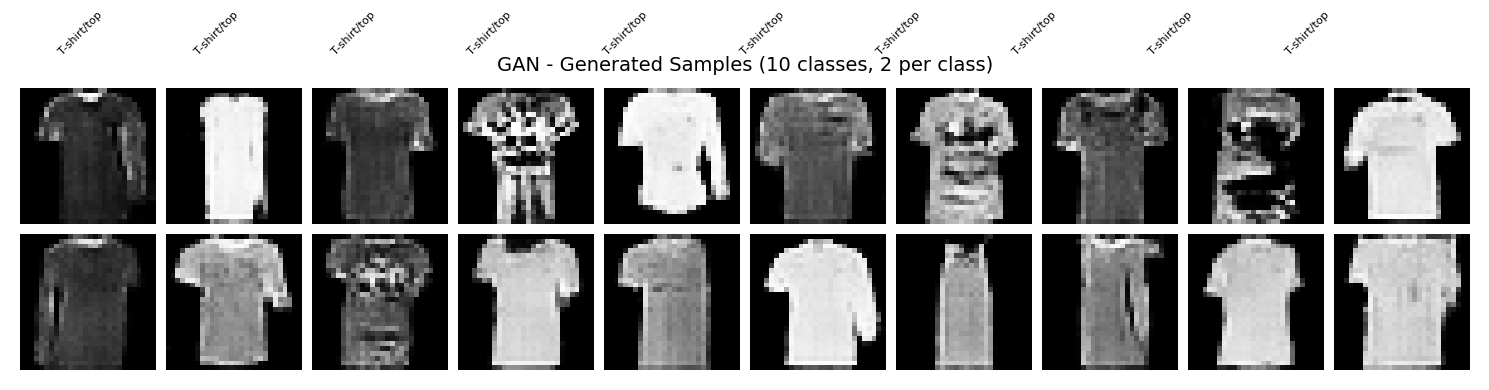

Saved: assets\evaluation_diffusion_samples.png


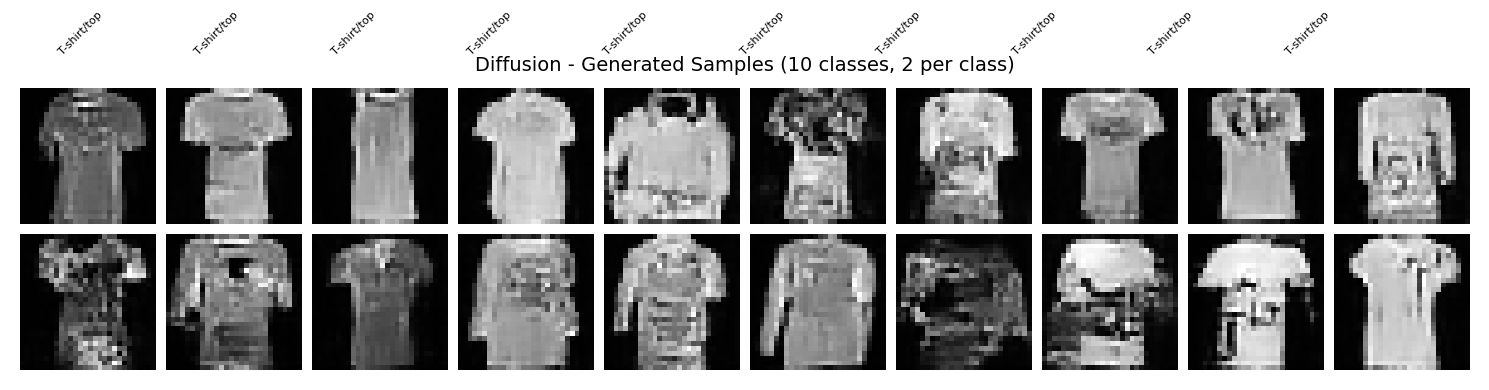

In [35]:
def visualize_samples(samples, labels, title, nrow=10, save_path=None):
    """Display a grid of generated samples; optionally save to ASSETS_DIR."""
    samples = samples[:20]  # Show first 20 samples
    grid = make_grid(samples, nrow=nrow, normalize=False, pad_value=1)
    
    plt.figure(figsize=(15, 4))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(title, fontsize=14)
    plt.axis('off')
    
    # Add class labels
    for i in range(10):
        li = labels[i].item() if hasattr(labels[i], "item") else int(labels[i])
        plt.text(i * 28 + 14, -5, class_names[li],
                 ha='center', va='bottom', fontsize=8, rotation=45)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

visualize_samples(
    gan_samples,
    gan_labels,
    "GAN - Generated Samples (10 classes, 2 per class)",
    save_path=os.path.join(ASSETS_DIR, "evaluation_gan_samples.png"),
)
visualize_samples(
    diffusion_samples,
    diffusion_labels,
    "Diffusion - Generated Samples (10 classes, 2 per class)",
    save_path=os.path.join(ASSETS_DIR, "evaluation_diffusion_samples.png"),
)

## 3. Feature Extractor for Metrics

We train a simple CNN classifier on real Fashion-MNIST data to extract features for FID, Precision, and Recall computation.

In [36]:
class FeatureExtractor(nn.Module):
    """CNN for feature extraction and classification on Fashion-MNIST"""
    def __init__(self, num_classes=10, feature_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        self.classifier = nn.Linear(128, num_classes)
    
    def forward(self, x, return_features=False):
        features = self.features(x)
        if return_features:
            return features
        return self.classifier(features)

# Train feature extractor on real data
def train_feature_extractor(model, train_loader, epochs=10, lr=0.001):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        epoch_loss = 0
        correct = 0
        total = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix(Loss=loss.item(), Acc=100.*correct/total)
    
    return model

# Create feature extractor
feature_extractor = FeatureExtractor().to(device)
print("Training feature extractor on real Fashion-MNIST...")
feature_extractor = train_feature_extractor(feature_extractor, train_loader, epochs=10)

# Evaluate on test set
feature_extractor.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = feature_extractor(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Feature extractor test accuracy: {100.*correct/total:.2f}%")

Training feature extractor on real Fashion-MNIST...


Epoch 10/10: 100%|██████████| 469/469 [00:26<00:00, 17.88it/s, Acc=88.2, Loss=0.343]


Feature extractor test accuracy: 87.33%


## 4. Compute Evaluation Metrics

### 4.1 FID (Fréchet Inception Distance)

FID measures the distance between real and generated feature distributions. Lower is better.

In [37]:
def compute_fid(real_features, fake_features):
    """Compute FID between real and fake feature distributions"""
    mu1 = np.mean(real_features, axis=0)
    mu2 = np.mean(fake_features, axis=0)
    sigma1 = np.cov(real_features, rowvar=False)
    sigma2 = np.cov(fake_features, rowvar=False)
    
    # Calculate sqrt of matrix product
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# Extract features from real data
def extract_features(model, dataloader, num_samples=None):
    """Extract features from images using the trained feature extractor"""
    model.eval()
    features = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            feat = model(images, return_features=True)
            features.append(feat.cpu().numpy())
            labels_list.append(labels.numpy())
            
            if num_samples and len(features) * BATCH_SIZE >= num_samples:
                break
    
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    
    if num_samples:
        features = features[:num_samples]
        labels = labels[:num_samples]
    
    return features, labels

# Extract features from real test data
real_features, real_labels = extract_features(feature_extractor, test_loader, NUM_SAMPLES)

# Extract features from GAN samples (same normalization as real data)
gan_dataloader = DataLoader(
    TensorDataset(
        torch.as_tensor(gan_feats_input, dtype=torch.float32),
        torch.as_tensor(gan_labels, dtype=torch.long),
    ),
    batch_size=BATCH_SIZE,
)
gan_features, _ = extract_features(feature_extractor, gan_dataloader, NUM_SAMPLES)

# Extract features from Diffusion samples
diffusion_dataloader = DataLoader(
    TensorDataset(
        torch.as_tensor(diffusion_feats_input, dtype=torch.float32),
        torch.as_tensor(diffusion_labels, dtype=torch.long),
    ),
    batch_size=BATCH_SIZE,
)
diffusion_features, diffusion_labels_extracted = extract_features(
    feature_extractor, diffusion_dataloader, NUM_SAMPLES
)

# Compute FID
fid_gan = compute_fid(real_features, gan_features)
fid_diffusion = compute_fid(real_features, diffusion_features)

print(f"GAN FID: {fid_gan:.4f}")
print(f"Diffusion FID: {fid_diffusion:.4f}")

Extracting features:  99%|█████████▊| 78/79 [00:01<00:00, 61.64it/s]


GAN FID: 2.0516
Diffusion FID: 15.1770


### 4.2 Precision and Recall

Precision measures sample quality (fraction of generated samples near real manifold).  
Recall measures diversity (fraction of real samples covered by generated distribution).

In [38]:
def compute_precision_recall(real_features, fake_features, k=3):
    """Compute precision and recall in feature space"""
    real_features = torch.tensor(real_features).float()
    fake_features = torch.tensor(fake_features).float()
    
    # Compute pairwise distances
    dist_real_to_fake = torch.cdist(real_features, fake_features)
    dist_fake_to_real = torch.cdist(fake_features, real_features)
    
    # For each real sample, find k-th nearest neighbor distance
    real_knn_dist = torch.topk(dist_real_to_fake, k, largest=False)[0][:, -1]
    threshold = torch.median(real_knn_dist)
    
    # Precision: fake samples within threshold of any real sample
    nearest_dist_to_real = dist_fake_to_real.min(dim=1)[0]
    precision = (nearest_dist_to_real < threshold).float().mean().item()
    
    # Recall: real samples within threshold of any fake sample
    nearest_dist_to_fake = dist_real_to_fake.min(dim=1)[0]
    recall = (nearest_dist_to_fake < threshold).float().mean().item()
    
    return precision, recall

precision_gan, recall_gan = compute_precision_recall(real_features, gan_features)
precision_diffusion, recall_diffusion = compute_precision_recall(real_features, diffusion_features)

print(f"GAN - Precision: {precision_gan:.4f}, Recall: {recall_gan:.4f}")
print(f"Diffusion - Precision: {precision_diffusion:.4f}, Recall: {recall_diffusion:.4f}")

GAN - Precision: 0.6071, Recall: 0.6529
Diffusion - Precision: 0.5907, Recall: 0.6768


### 4.3 Conditional Classification Accuracy

This metric measures how well generated samples match their intended class labels.

In [23]:
def compute_conditional_accuracy(classifier, samples, labels):
    """Check if generated samples match their intended classes"""
    classifier.eval()
    labels = torch.as_tensor(labels, dtype=torch.long)
    correct = 0
    total = labels.shape[0]
    per_class_correct = [0] * NUM_CLASSES
    per_class_total = [0] * NUM_CLASSES
    
    with torch.no_grad():
        for i in range(0, total, BATCH_SIZE):
            batch_samples = samples[i:i+BATCH_SIZE].to(device)
            batch_labels = labels[i:i+BATCH_SIZE].to(device)
            
            outputs = classifier(batch_samples)
            predictions = outputs.argmax(dim=1)
            
            for j in range(len(batch_labels)):
                true_label = batch_labels[j].item()
                per_class_total[true_label] += 1
                if predictions[j] == batch_labels[j]:
                    correct += 1
                    per_class_correct[true_label] += 1
    
    accuracy = correct / total
    per_class_accuracy = [per_class_correct[i] / per_class_total[i] if per_class_total[i] > 0 else 0 
                          for i in range(NUM_CLASSES)]
    
    return accuracy, per_class_accuracy

gan_acc, gan_per_class = compute_conditional_accuracy(
    feature_extractor, gan_feats_input, gan_labels
)
diffusion_acc, diffusion_per_class = compute_conditional_accuracy(
    feature_extractor, diffusion_feats_input, diffusion_labels
)

print(f"GAN Conditional Accuracy: {gan_acc:.4f} ({gan_acc*100:.2f}%)")
print(f"Diffusion Conditional Accuracy: {diffusion_acc:.4f} ({diffusion_acc*100:.2f}%)")

GAN Conditional Accuracy: 0.8763 (87.63%)
Diffusion Conditional Accuracy: 0.7944 (79.44%)


## 5. Results Summary

Saved: assets\evaluation_metrics_table.png


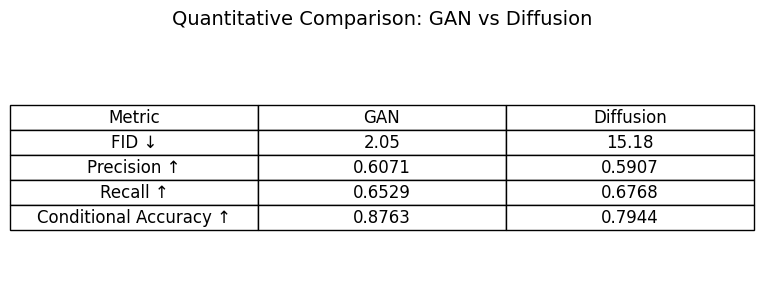

In [39]:
results = {
    'Metric': ['FID ↓', 'Precision ↑', 'Recall ↑', 'Conditional Accuracy ↑'],
    'GAN': [f'{fid_gan:.2f}', f'{precision_gan:.4f}', f'{recall_gan:.4f}', f'{gan_acc:.4f}'],
    'Diffusion': [f'{fid_diffusion:.2f}', f'{precision_diffusion:.4f}', f'{recall_diffusion:.4f}', f'{diffusion_acc:.4f}']
}

# Display results
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
table = ax.table(cellText=list(zip(results['Metric'], results['GAN'], results['Diffusion'])),
                 colLabels=['Metric', 'GAN', 'Diffusion'],
                 loc='center',
                 cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title("Quantitative Comparison: GAN vs Diffusion", fontsize=14, pad=20)
_metrics_fig = os.path.join(ASSETS_DIR, "evaluation_metrics_table.png")
plt.savefig(_metrics_fig, dpi=220, bbox_inches="tight")
print(f"Saved: {_metrics_fig}")
plt.show()

Saved: assets\evaluation_per_class_accuracy.png


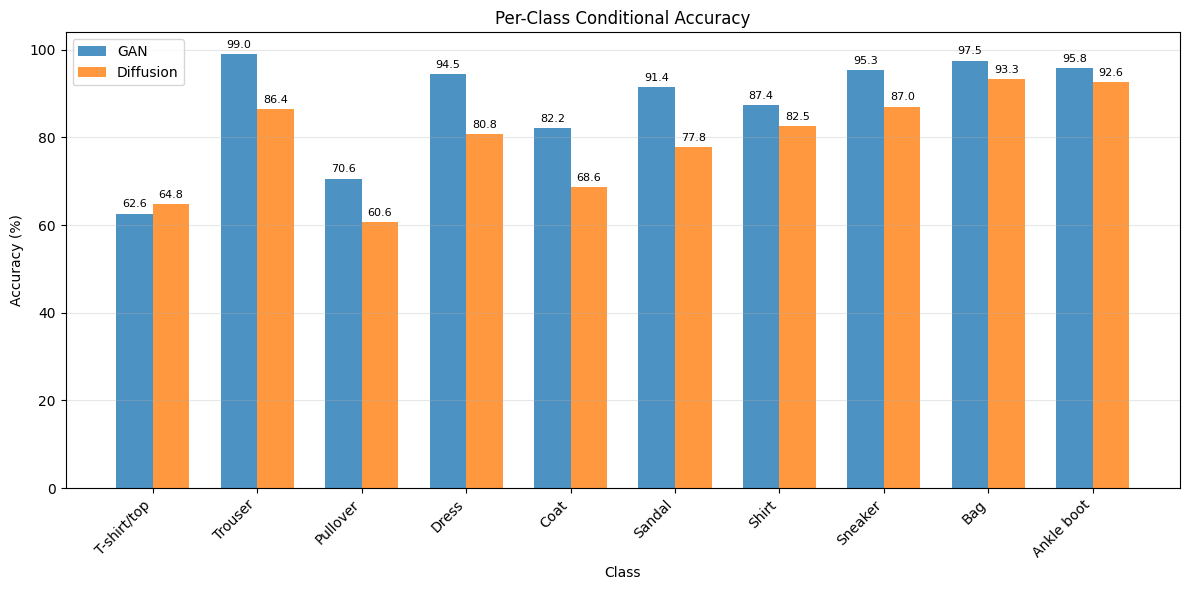

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(NUM_CLASSES)
width = 0.35

bars1 = ax.bar(x - width/2, [acc * 100 for acc in gan_per_class], width, label='GAN', alpha=0.8)
bars2 = ax.bar(x + width/2, [acc * 100 for acc in diffusion_per_class], width, label='Diffusion', alpha=0.8)

ax.set_xlabel('Class')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Conditional Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
_acc_fig = os.path.join(ASSETS_DIR, "evaluation_per_class_accuracy.png")
plt.savefig(_acc_fig, dpi=220, bbox_inches="tight")
print(f"Saved: {_acc_fig}")
plt.show()